In [2]:
import numpy as np
import matplotlib.pyplot as plt
import illustris_python as il
import random
import h5py
from scipy import stats

In [3]:
import seaborn as sns
palette_tab10 = sns.color_palette("colorblind", 10)

In [4]:
color_list = palette_tab10[2:3] + palette_tab10[4:5] + palette_tab10[1:2] 

In [5]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

In [6]:
snapnum = 40

In [7]:
basePath = '/cosma7/data/dp004/dc-zhan5/TNG300-1'

In [8]:
fields = ['GroupFirstSub', "GroupSFR", "GroupMass", "GroupNsubs", 
          "GroupPos", "GroupMassType", "GroupBHMass", "Group_M_TopHat200", "Group_M_Crit200"]
header = il.groupcat.loadHeader(f"{basePath}/output", snapnum)
halos = il.groupcat.loadHalos(f"{basePath}/output", snapnum, fields=fields)

In [9]:
h0 = 0.6774

In [10]:
mvir = np.log10(halos["Group_M_TopHat200"]*1e10)

/tmp/ipykernel_1210039/565162213.py:1: RuntimeWarning: divide by zero encountered in log10
  mvir = np.log10(halos["Group_M_TopHat200"]*1e10)


In [11]:
group_sfrs = np.log10(halos["GroupSFR"])
#group_sfrs = halos["GroupSFR"]

/tmp/ipykernel_1210039/1790768633.py:1: RuntimeWarning: divide by zero encountered in log10
  group_sfrs = np.log10(halos["GroupSFR"])


In [12]:
fields = ["SubhaloSFR", # [Msun/yr]
          "SubhaloGrNr",
         "SubhaloFlag",
         "SubhaloPos",
         "SubhaloCM", "SubhaloHalfmassRad", "SubhaloHalfmassRadType", "SubhaloMass", "SubhaloBHMass",
         "SubhaloMassType", "SubhaloVmax", "SubhaloVmaxRad"] # [10^10 Msun/h]
print(len(fields))
subhalos = il.groupcat.loadSubhalos(f"{basePath}/output", snapnum, fields=fields)
print(type(subhalos))

12


<class 'dict'>


In [13]:
vmax = subhalos["SubhaloVmax"]
rmax = subhalos["SubhaloVmaxRad"]

In [14]:
cent_vmax1 = subhalos["SubhaloVmax"][halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]]
cent_vmax = np.zeros(len(mvir))
cent_vmax[halos["GroupFirstSub"]>-1] = cent_vmax1

In [15]:
cent_rmax1 = subhalos["SubhaloVmaxRad"][halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]]
cent_rmax = np.zeros(len(mvir))
cent_rmax[halos["GroupFirstSub"]>-1] = cent_rmax1

In [16]:
cent_cprox = cent_vmax/cent_rmax

/tmp/ipykernel_1210039/2104352924.py:1: RuntimeWarning: invalid value encountered in divide
  cent_cprox = cent_vmax/cent_rmax


In [17]:
cent_mask_all = np.full(len(subhalos["SubhaloSFR"]), False)
cent_mask_all[halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]] = True

In [18]:
cent_sfrs1 = subhalos["SubhaloSFR"][halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]]

In [19]:
cent_sfrs = np.zeros(len(mvir))
cent_sfrs[halos["GroupFirstSub"]>-1] = cent_sfrs1
cent_sfrs = np.log10(cent_sfrs)

/tmp/ipykernel_1210039/2662205001.py:3: RuntimeWarning: divide by zero encountered in log10
  cent_sfrs = np.log10(cent_sfrs)


### Satellite SFR

In [20]:
sat_sfrs = subhalos["SubhaloSFR"][~cent_mask_all]

In [21]:
sat_mass = subhalos["SubhaloMass"][~cent_mask_all]*1e10

In [22]:
sat_ids = subhalos["SubhaloGrNr"][~cent_mask_all]
unique_ids, indices = np.unique(sat_ids, return_index=True)

In [23]:
sum_sfrs1 = np.add.reduceat(sat_sfrs, indices)

In [24]:
sum_sfrs = np.zeros(len(group_sfrs))
sum_sfrs[unique_ids] = sum_sfrs1
sum_sfrs = np.log10(sum_sfrs)

/tmp/ipykernel_1210039/1283956768.py:3: RuntimeWarning: divide by zero encountered in log10
  sum_sfrs = np.log10(sum_sfrs)


In [25]:
sum_mass1 =  np.add.reduceat(sat_mass, indices)

In [26]:

sum_sat_mass = np.zeros(len(group_sfrs))
sum_sat_mass[unique_ids] = sum_mass1
sum_sat_mass = np.log10(sum_sat_mass)

/tmp/ipykernel_1210039/2587338875.py:3: RuntimeWarning: divide by zero encountered in log10
  sum_sat_mass = np.log10(sum_sat_mass)


In [27]:
sfr_types = [cent_sfrs, sum_sfrs, group_sfrs]

In [37]:
dlogM = 0.1
mbins = np.arange(10,13.71,dlogM)
mbins2 = np.array([13.8, 14.2])
mbins = np.concatenate((mbins, mbins2))
mbin_cents = (mbins[1:] + mbins[:-1])/2


coef_list = []
perr_list = []
for i, m in enumerate(mbins[:-1]):
    mask = (mvir > mbins[i]) & (mvir < mbins[i+1]) & (group_sfrs > -5) #& (np.isnan(frac_cent) == False)#& (np.isnan(c200c)==False)
    # frac = np.sum(mask)/np.sum((mvir > mcent - dlogM/2) & (mvir < mcent + dlogM/2) )
    # frac_list.append(frac)
    coef1 = stats.spearmanr(cent_sfrs[mask],sum_sfrs[mask])
    coef = coef1[0]
    perr = coef1[1]
    #print(np.sum(mask & (sum_sfrs>-5)))
    if np.sum(mask) < 5:
        coef = np.nan
        #print(mcent)
    coef_list.append(coef)
    perr_list.append(perr)


3799
5868
8392
11262
14439
17054
19327
21114
21736
20843
20238
18844
16623
15178
13317
11581
10012
8665
7122
6072
4955
3981
3086
2524
1781
1306
992
720
514
364
268
173
127
101
63
45
19
12
25


Text(0.1, 0.85, '$r_\\mathrm{s} = -0.1$')

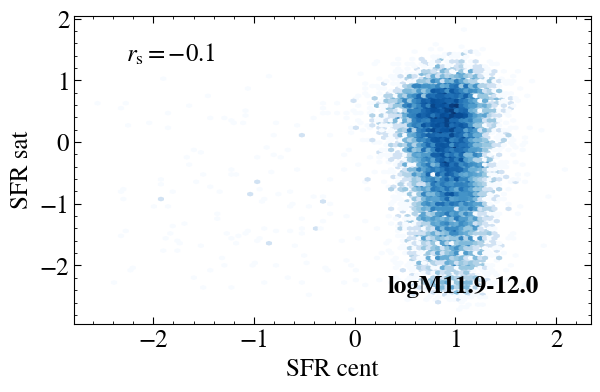

In [48]:
m = 11.9
dlogM=0.1
mask = (mvir > m - dlogM) & (mvir < m + dlogM) & (group_sfrs > -5) 
for itype in range(2,3):
    x = cent_sfrs[mask]
    y = sum_sfrs[mask]
    coef = stats.spearmanr(x,y)[0]
    #plt.scatter(np.log10(x), y, s=0.1, label=sfr_type_names[itype])
#plt.legend(loc="lower right", markerscale=10)
plt.ylabel(r"SFR sat")
plt.xlabel(r"SFR cent")
hb = plt.hexbin(x, y, gridsize=100, cmap='Blues', bins="log",mincnt=1)

logM_name = f"logM{m}-{np.round(m+0.1,1)}"
plt.annotate(f"{logM_name}", (0.9,0.1), xycoords="axes fraction", ha="right", weight="bold")
plt.annotate(rf"$r_\mathrm{{s}} = {np.round(coef,2)}$", (0.1,0.85), xycoords="axes fraction", ha="left")
#plt.savefig(f"../figures/sfr_msat_{logM_name}.pdf", format="pdf", bbox_inches="tight")

(11.0, 14.4)

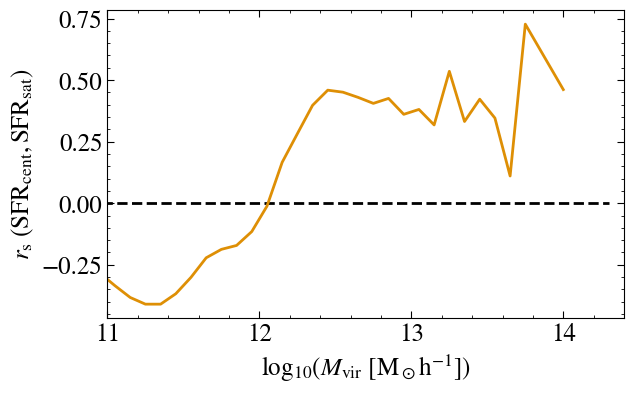

In [29]:
plt.plot([10,14.3], [0,0], linestyle="dashed", c="k")

plt.plot(mbin_cents, coef_list, color=color_list[2])


plt.xlabel(r"log$_{10} (M_{\rm vir}$ [M$_\odot$h$^{-1}$])")
plt.ylabel(r"$r_\mathrm{s}\ \rm(SFR_{cent}, SFR_{sat})$")
# ax = plt.gca()
# h, l =  ax.get_legend_handles_labels()
# leg1 = plt.legend(handles=h[2:], labels=l[2:], loc = "lower right", ncol=2)
# ax.add_artist(leg1)
# leg2 = plt.legend(handles=h[:2], labels=l[:2], loc = "upper left", bbox_to_anchor=(0,0.9))
plt.xlim(11,14.4)
#plt.savefig("../figures/corr_coef_sfr_cent_sat.pdf", format="pdf", bbox_inches="tight")

In [30]:
dlogM = 0.1
mbins = np.arange(10,13.71,dlogM)
mbins2 = np.array([13.8, 14.3])
mbins = np.concatenate((mbins, mbins2))
mbin_cents = (mbins[1:] + mbins[:-1])/2

coef_lists1 =[]
for itype in range(1):
    coef_list = []
    for i, m in enumerate(mbins[:-1]):
        mask = (mvir > mbins[i]) & (mvir < mbins[i+1]) & (group_sfrs > -5) #& (np.isnan(frac_cent) == False)#& (np.isnan(c200c)==False)
        # frac = np.sum(mask)/np.sum((mvir > mcent - dlogM/2) & (mvir < mcent + dlogM/2) )
        # frac_list.append(frac)
        if np.sum(mask) > 0:
            percentiles = np.percentile(sfr_types[itype][mask], 99)
            median = np.median(sfr_types[itype][mask])
            diff = percentiles-median
            low_lim = median-diff
            mask = mask & (sfr_types[itype] > low_lim)
        coef = stats.spearmanr(cent_sfrs[mask],sum_sfrs[mask])[0]
        
        
        if np.sum(mask) < 5:
            coef = np.nan
            #print(mcent)
        coef_list.append(coef)
    coef_lists1.append(coef_list)

(11.0, 14.4)

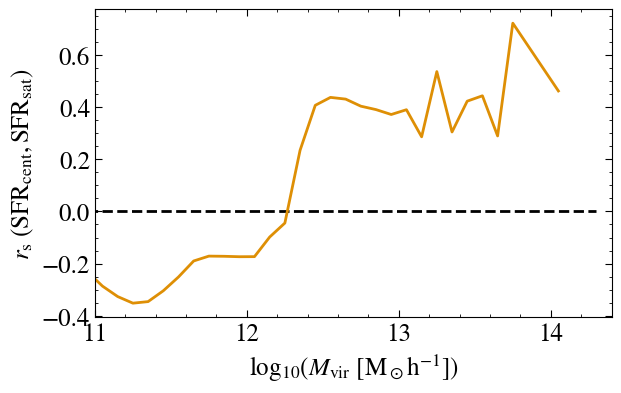

In [31]:
plt.plot([10,14.3], [0,0], linestyle="dashed", c="k")

plt.plot(mbin_cents, coef_lists1[0], color=color_list[2])

plt.xlabel(r"log$_{10} (M_{\rm vir}$ [M$_\odot$h$^{-1}$])")
plt.ylabel(r"$r_\mathrm{s}\ \rm(SFR_{cent}, SFR_{sat})$")
# ax = plt.gca()
# h, l =  ax.get_legend_handles_labels()
# leg1 = plt.legend(handles=h[2:], labels=l[2:], loc = "lower right", ncol=2)
# ax.add_artist(leg1)
# leg2 = plt.legend(handles=h[:2], labels=l[:2], loc = "upper left", bbox_to_anchor=(0,0.9))
plt.xlim(11,14.4)
#plt.savefig("../figures/corr_coef_sfr_cent_sat.pdf", format="pdf", bbox_inches="tight")

In [32]:
percentiles = np.nanpercentile(cent_cprox, 75)
print(percentiles)

3.0675876214771787


In [33]:
dlogM = 0.1
mbins = np.arange(10,13.71,dlogM)
mbins2 = np.array([13.8, 14.2])
mbins = np.concatenate((mbins, mbins2))
mbin_cents = (mbins[1:] + mbins[:-1])/2


coef_list = []
perr_list = []
for i, m in enumerate(mbins[:-1]):
    
    mask = (mvir > mbins[i]) & (mvir < mbins[i+1]) & (group_sfrs > -5) 
    percentile = np.nanpercentile(cent_cprox[mask], 75)
    mask = mask & (cent_cprox > percentile)
    # frac = np.sum(mask)/np.sum((mvir > mcent - dlogM/2) & (mvir < mcent + dlogM/2) )
    # frac_list.append(frac)
    coef1 = stats.spearmanr(cent_sfrs[mask],sum_sfrs[mask])
    coef = coef1[0]
    perr = coef1[1]
    if np.sum(mask) < 5:
        coef = np.nan
        #print(mcent)
    coef_list.append(coef)
    perr_list.append(perr)

(11.0, 14.4)

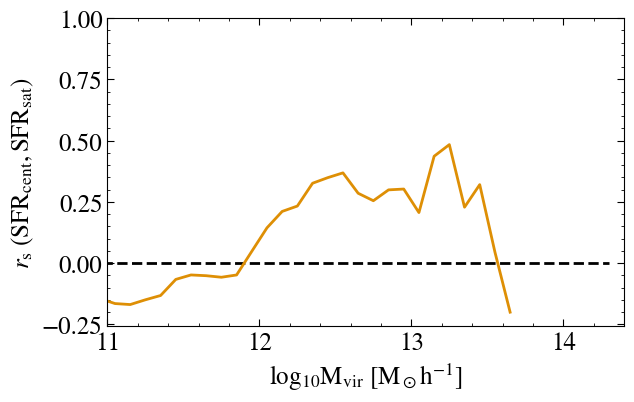

In [34]:
plt.plot([10,14.3], [0,0], linestyle="dashed", c="k")

plt.plot(mbin_cents, coef_list, color=color_list[2])

plt.xlabel(r"log$_{10}$M$_{\rm vir}$ [M$_\odot$h$^{-1}$]")
plt.ylabel(r"$r_\mathrm{s}\ \rm(SFR_{cent}, SFR_{sat})$")
# ax = plt.gca()
# h, l =  ax.get_legend_handles_labels()
# leg1 = plt.legend(handles=h[2:], labels=l[2:], loc = "lower right", ncol=2)
# ax.add_artist(leg1)
# leg2 = plt.legend(handles=h[:2], labels=l[:2], loc = "upper left", bbox_to_anchor=(0,0.9))
plt.xlim(11,14.4)
#plt.savefig("../figures/corr_coef_sfr_cent_sat.pdf", format="pdf", bbox_inches="tight")

In [202]:
logM = 12.6
dlogM=0.1
mask_mass = (mvir > logM) & (mvir < logM+dlogM)

In [203]:
percentiles_list = [0, 25, 50, 75, 100]

In [204]:
property1 = cent_cprox

In [205]:
percentiles = np.nanpercentile(property1[mask_mass], percentiles_list)

In [206]:
print(percentiles)

[7.54655253e-01 1.53695149e+00 2.25738910e+00 4.31245452e+00
 8.60219602e+03]
